In [1]:
import numpy as np
import matplotlib.pyplot as plt
from source.random_walk import generate_random_walk
from source.plot_tools import activity_map


def oscillatory_interference_signal(
    velocity, dt, f0=8.0, beta=1.2, pref_dirs_deg=(0, 60, 120)
):
    n_steps = velocity.shape[0]

    t = np.arange(n_steps) * dt
    soma_phase = 2 * np.pi * f0 * t

    interference = np.zeros(n_steps)
    for theta_deg in pref_dirs_deg:
        theta = np.deg2rad(theta_deg)
        d_vec = np.array([np.cos(theta), np.sin(theta)])
        v_proj = velocity @ d_vec
        freq = f0 + beta * v_proj
        dendritic_phase = 2 * np.pi * np.cumsum(freq) * dt
        interference += np.cos(dendritic_phase - soma_phase)

    return interference

def signal_to_spikes(interference, n_dirs, threshold_frac=0.85, rng=None):
    rng = rng or np.random.default_rng(1)
    peak = n_dirs
    thresh = threshold_frac * peak
    firing_drive = np.clip(interference - thresh, 0, None)
    spikes = rng.random(len(interference)) < firing_drive
    return spikes


def compute_rate_map(position, spikes, box_size, bins=40):
    spike_pos = position[spikes]
    spike_counts, xedges, yedges = np.histogram2d(
        spike_pos[:, 0],
        spike_pos[:, 1],
        bins=bins,
        range=[[0, box_size], [0, box_size]],
    )
    occupancy, _, _ = np.histogram2d(
        position[:, 0], position[:, 1], bins=bins, range=[[0, box_size], [0, box_size]]
    )
    occupancy_safe = np.where(occupancy > 0, occupancy, np.nan)
    rate_map = spike_counts / occupancy_safe
    return rate_map, xedges, yedges

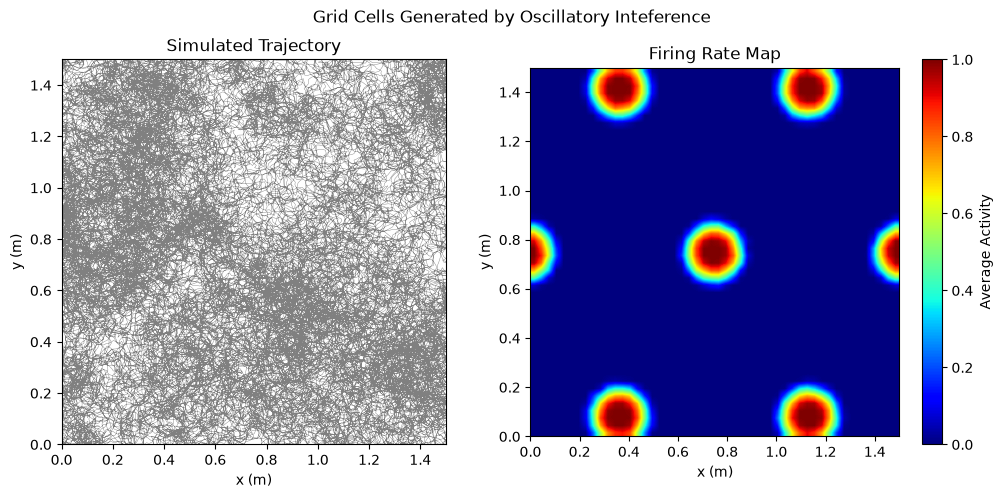

In [2]:
dt = 0.5e-3
T = 2000
box_size = 1.5
rng = np.random.default_rng(0)


position, velocity, time = generate_random_walk(T, dt, box_size, rng = rng)
n_steps = position.shape[0]


f0 = 8.0
beta = 1.5
pref_dirs_deg = (0, 60, 120)

interference = oscillatory_interference_signal(
    velocity, dt, f0=f0, beta=beta, pref_dirs_deg=pref_dirs_deg
)
spikes = signal_to_spikes(
    interference,
    n_dirs=len(pref_dirs_deg),
    threshold_frac=0.6,
    rng=rng,
)

binned_activity, edges = activity_map(position, spikes)
fig, ax = plt.subplots(
    1, 2, figsize=(12, 5), gridspec_kw={"width_ratios": (1, 1.2)}
)
cb = ax[1].imshow(
    binned_activity, origin="lower", extent=[0, box_size, 0, box_size], cmap="jet",interpolation="bilinear",
)
ax[1].set_xlabel("x (m)")
ax[1].set_ylabel("y (m)")
ax[1].set_title("Firing Rate Map")
fig.colorbar(cb, ax=ax[1], label="Average Activity")

ax[0].set_title("Simulated Trajectory")
ax[0].plot(position[:,0], position[:,1], lw=0.3, color="gray")
ax[0].set_xlabel("x (m)")
ax[0].set_ylabel("y (m)")
ax[0].set_xlim((0, box_size))
ax[0].set_ylim((0, box_size))
fig.suptitle("Grid Cells Generated by Oscillatory Inteference")
fig.savefig("plots/oi_grid_cells.png")